# Banking Financial Health Classification: Exploratory Data Analysis

**Project:** ARB Apex Bank - Rural Banking Risk Assessment System  
---

## Objective
Perform comprehensive exploratory data analysis on the synthetic banking dataset to:
1. Understand data distributions and characteristics
2. Identify patterns in financial health status
3. Detect correlations and multicollinearity
4. Analyze temporal trends across 12 quarters
5. Compare regional differences in bank performance
6. Inform feature engineering and modeling decisions

## Analysis Structure
1. Data Loading & Initial Assessment
2. Univariate Analysis
3. Target Variable Analysis
4. Bivariate Analysis (Risk vs Features)
5. Correlation Analysis & Multicollinearity
6. Temporal Analysis (Quarterly Trends)
7. Regional Comparison
8. Missing Value Analysis
9. Key Findings Summary

# Setup and Data Loading 


In [6]:
# import libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats 
import warnings

# configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

#plotting configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print('Libraries loaded successfully...')

Libraries loaded successfully...


In [7]:
# Load dataset 
data_path = 'data/raw/banking_data_raw.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded successfully...")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows")
df.head()

Dataset loaded successfully...
Shape: (2688, 35)

First few rows


,bank_id,bank_name,region,bank_size,lending_style,quarter_num,year,quarter,date,total_assets,total_equity,liquid_assets,total_loans,non_performing_loans,loan_loss_provisions,current_deposits,liquidity_ratio,capital_adequacy_ratio,cash_reserve_ratio,leverage_ratio,loan_to_deposit_ratio,npl_ratio,net_income,return_on_assets,return_on_equity,net_interest_margin,operating_expenses,cost_to_income_ratio,staff_count,branches,concentration_risk,deposit_volatility,financial_health_status,consecutive_losses,risk_reasons
0,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,1,2021,Q1,2021-Q1,47.72,7.98,8.70,17.48,1.09,0.96,36.87,18.24,16.73,22.31,19.31,47.43,6.24,2.46,5.16,30.85,11.55,1.80,70.52,57.0,6.0,30.82,17.38,0,0,NaN
1,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,2,2021,Q2,2021-Q2,49.23,8.37,8.75,15.48,1.00,1.18,35.03,17.77,17.00,21.43,11.90,44.18,6.48,2.20,4.47,26.32,7.21,1.69,92.28,80.0,10.0,49.16,26.72,0,0,NaN
2,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,3,2021,Q3,2021-Q3,44.00,7.48,7.43,26.73,1.86,0.99,35.37,16.88,17.00,18.00,18.55,75.57,6.95,2.74,6.22,36.58,7.56,2.36,50.34,29.0,11.0,23.67,8.46,0,0,NaN
3,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,4,2021,Q4,2021-Q4,47.60,8.06,8.10,15.73,1.15,1.10,36.57,17.02,16.94,14.20,16.18,43.02,7.31,1.80,3.78,22.31,6.81,3.53,64.47,55.0,7.0,40.76,29.12,0,0,NaN
4,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,5,2022,Q1,2022-Q1,51.87,8.83,9.01,27.19,2.02,1.66,39.63,17.36,17.02,24.84,16.07,68.61,7.43,0.53,1.03,6.05,3.85,2.55,90.62,25.0,2.0,17.37,7.66,0,0,NaN


# Data Assessment 


In [17]:
#Basic info
print("Dataset Information:")
print("-"*70)
df.info()


Dataset Information:
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688 entries, 0 to 2687
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   bank_id                  2688 non-null   object 
 1   bank_name                2688 non-null   object 
 2   region                   2688 non-null   object 
 3   bank_size                2688 non-null   object 
 4   lending_style            2688 non-null   object 
 5   quarter_num              2688 non-null   int64  
 6   year                     2688 non-null   int64  
 7   quarter                  2688 non-null   object 
 8   date                     2688 non-null   object 
 9   total_assets             2688 non-null   float64
 10  total_equity             2688 non-null   float64
 11  liquid_assets            2688 non-null   float64
 12  total_loans              2688 non-null  

In [18]:
# Descriptive statistics 
print("\nDescriptive Statistics:")
print("-" * 70)
df.describe().T



Descriptive Statistics:
----------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
quarter_num,2688.0,6.50,3.45,1.00,3.75,6.50,9.25,12.00
year,2688.0,2022.00,0.82,2021.00,2021.00,2022.00,2023.00,2023.00
total_assets,2688.0,140.95,193.27,4.80,26.65,66.16,162.69,1322.15
total_equity,2688.0,25.17,35.63,0.44,4.40,12.42,30.66,297.50
liquid_assets,2688.0,36.40,54.63,0.60,6.17,15.51,41.75,521.61
total_loans,2688.0,73.29,105.30,1.46,13.55,35.05,84.95,925.25
non_performing_loans,2688.0,6.37,10.03,0.04,0.88,2.57,7.15,94.63
loan_loss_provisions,2688.0,5.41,8.98,0.03,0.72,2.09,6.06,79.66
current_deposits,2688.0,109.18,150.36,3.41,20.94,51.22,126.32,1096.32
liquidity_ratio,2688.0,25.65,8.91,4.29,19.96,25.55,31.67,48.96


In [21]:
# check unique values in categorical columns 
categorical_cols = ['bank_id', 'region', 'bank_size', 'lending_style', 'quarter', 'date']

print("\nCategorical Variables - Unique Values")
print("-" * 70)
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}")
        print(f" Unique count: {df[col].nunique()}")
        if df[col].nunique() <= 15:
            print(f" Values: {df[col].unique()}")


Categorical Variables - Unique Values
----------------------------------------------------------------------

bank_id
 Unique count: 224

region
 Unique count: 10
 Values: ['Upper West' 'Greater Accra' 'Volta' 'Central' 'Eastern' 'Western'
 'Ashanti' 'Northern' 'Upper East' 'Bono']

bank_size
 Unique count: 3
 Values: ['Small' 'Large' 'Medium']

lending_style
 Unique count: 3
 Values: ['Moderate' 'Conservative' 'Aggressive']

quarter
 Unique count: 4
 Values: ['Q1' 'Q2' 'Q3' 'Q4']

date
 Unique count: 12
 Values: ['2021-Q1' '2021-Q2' '2021-Q3' '2021-Q4' '2022-Q1' '2022-Q2' '2022-Q3'
 '2022-Q4' '2023-Q1' '2023-Q2' '2023-Q3' '2023-Q4']


In [29]:
print("\nDataset Validation:")
print("-"*70)
print(f"Number of banks: {df['bank_id'].nunique()}")
print(f"Number of quarters: {df['quarter_num'].nunique()}")
print(f"Total records: {len(df)}")
print(f"Number of features: {df.shape[1]}")
print(f"Regions: {df['region'].nunique()}")

# Validate duplicates 
duplicates = df.duplicated(subset=['bank_id', 'quarter_num']).sum()
print(f"Duplicate records: {duplicates}")


Dataset Validation:
----------------------------------------------------------------------
Number of banks: 224
Number of quarters: 12
Total records: 2688
Number of features: 35
Regions: 10
Duplicate records: 0


# Target Variable Analysis 

In [32]:
target_counts = df['financial_health_status'].value_counts()
target_pct = df['financial_health_status'].value_counts(normalize=True)*100

print("Target Variable Distribution:..")
print("-"*70)
print(f"\nHEALTHY (0): {target_counts[0]:,} records ({target_pct[0]:.1f}%)")
print(f"\nHIGH_RISK (1): {target_counts[1]:,} records ({target_pct[1]:.1f}%)")
print(f"\nClass Imbalance Ratio: 1:{target_counts[0]/target_pct[1]:.2f}")

Target Variable Distribution:..
----------------------------------------------------------------------

HEALTHY (0): 1,767 records (65.7%)

HIGH_RISK (1): 921 records (34.3%)

Class Imbalance Ratio: 1:51.57


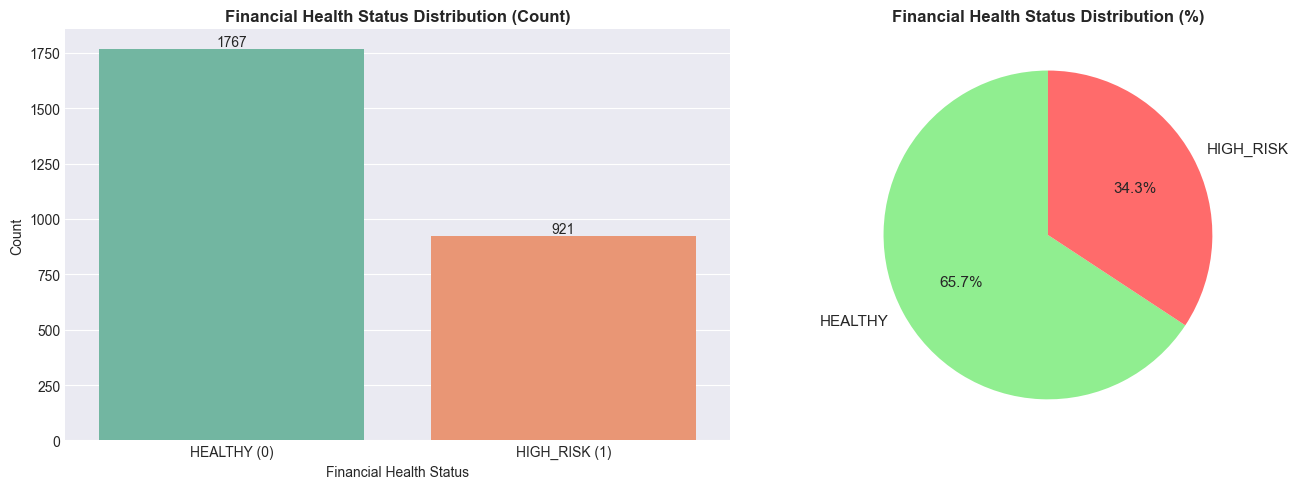

In [39]:
# Visualize target distribution 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot 
sns.countplot(data=df, x='financial_health_status', ax=axes[0], palette='Set2')
axes[0].set_title('Financial Health Status Distribution (Count)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Financial Health Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['HEALTHY (0)', 'HIGH_RISK (1)'])

# Add count labels 
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart 
colors = ['#90EE90', '#FF6B6B']
axes[1].pie(target_counts, labels=['HEALTHY', 'HIGH_RISK'], autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Financial Health Status Distribution (%)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [41]:
# Analyze risk distribution by bank size 
print("\nRisk Distribution by Bnak size:")
print("-"*70)
risk_by_size = pd.crosstab(df['bank_size'], df['financial_health_status'],
                          normalize='index'
                          
                          )* 100
risk_by_size.columns = ['HEALTHY (%)', 'HIGH_RISK (%)']
print(risk_by_size.round(1))


Risk Distribution by Bnak size:
----------------------------------------------------------------------
           HEALTHY (%)  HIGH_RISK (%)
bank_size                            
Large             57.8           42.2
Medium            72.1           27.9
Small             62.3           37.7


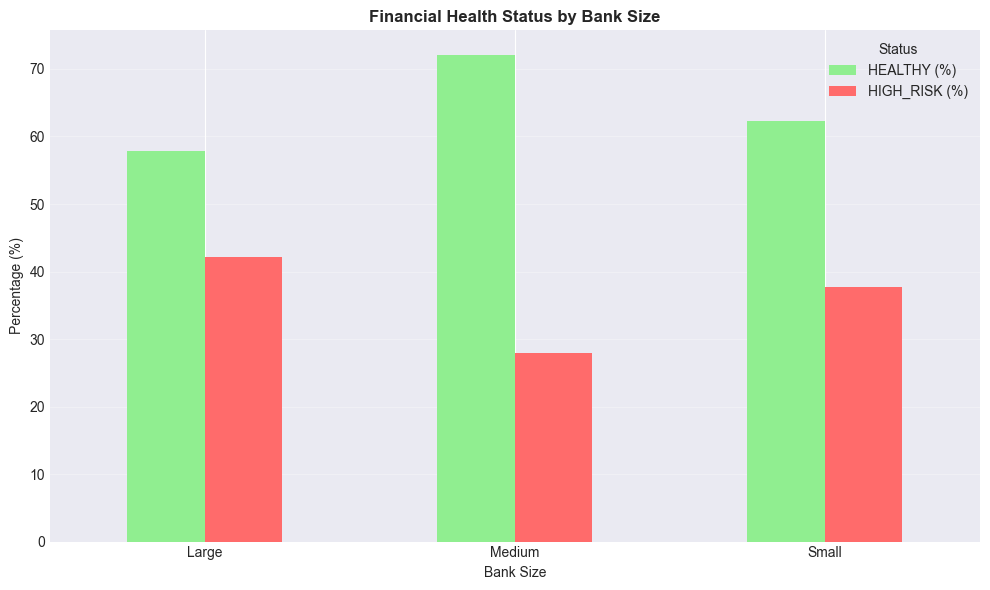

In [44]:
# visualize 
fig, ax = plt.subplots(figsize=(10, 6))
risk_by_size.plot(kind='bar', ax=ax, color=['#90EE90', '#FF6B6B'])
ax.set_title('Financial Health Status by Bank Size', fontweight='bold', fontsize=12)
ax.set_xlabel('Bank Size')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Status', loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Analyze risk distribution by region
print("\nRisk Distribution by Region:")
print("-" * 70)
risk_by_region = pd.crosstab(df['region'], df['financial_health_status'], 
                              normalize='index') * 100
risk_by_region.columns = ['HEALTHY (%)', 'HIGH_RISK (%)']
risk_by_region = risk_by_region.sort_values('HIGH_RISK (%)', ascending=False)
print(risk_by_region.round(1))



In [ ]:
# Visualize top/bottom regions
fig, ax = plt.subplots(figsize=(12, 6))
risk_by_region['HIGH_RISK (%)'].plot(kind='barh', ax=ax, color='#FF6B6B')
ax.set_title('High-Risk Percentage by Region (Sorted)', fontweight='bold', fontsize=12)
ax.set_xlabel('High-Risk Percentage (%)')
ax.set_ylabel('Region')
ax.axvline(x=risk_by_region['HIGH_RISK (%)'].mean(), color='red', 
           linestyle='--', linewidth=2, label='Average')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()